In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
Data=pd.read_csv("shop_smart_ecommerce.csv")
Data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [67]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le=LabelEncoder()
Data["Weekendl"]=le.fit_transform(Data["Weekend"])
Data["Revenued"]=le.fit_transform(Data["Revenue"])
Data.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Weekendl,Revenued
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False,1,0


In [68]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    drop='first'
)

encoded = ohe.fit_transform(Data[["VisitorType"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["VisitorType"]),
    index=Data.index
)

encoded_df.head()

,VisitorType_Other,VisitorType_Returning_Visitor
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0


In [69]:
Data=pd.concat([Data.drop(columns="VisitorType"),encoded_df],axis=1)

In [70]:
Data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Weekendl,Revenued,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,1,1,1,False,False,0,0,0.0,1.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,2,2,1,2,False,False,0,0,0.0,1.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,4,1,9,3,False,False,0,0,0.0,1.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,3,2,2,4,False,False,0,0,0.0,1.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,3,3,1,4,True,False,1,0,0.0,1.0


In [71]:
# Two columns are repeating droping some duplicated columns
Data=Data.drop(columns=["Weekend","Revenue"])

In [72]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  Month                          12330 non-null  object 
 11  OperatingSystems               12330 non-null  int64  
 12  Browser                        12330 non-null 

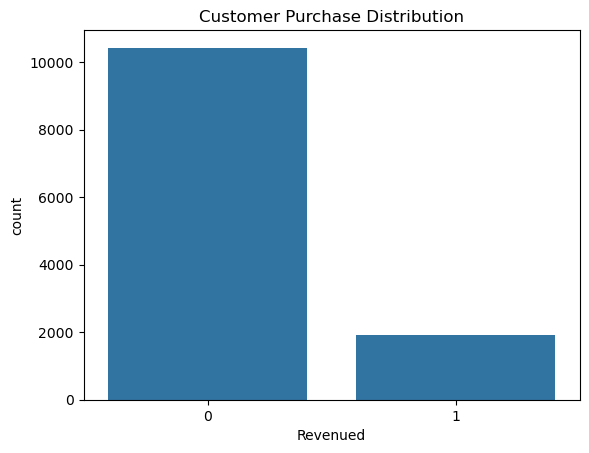

<Figure size 640x480 with 0 Axes>

In [73]:
# Doing some Exopisitory data analysis
sns.countplot(x="Revenued", data=Data)

plt.title("Customer Purchase Distribution")
plt.show()
plt.savefig("Customer Purchase Distribution.png")

In [74]:
# purchase percentage
print(Data["Revenued"].value_counts())

print(Data["Revenued"].value_counts(normalize=True)*100)

Revenued
0    10422
1     1908
Name: count, dtype: int64
Revenued
0    84.525547
1    15.474453
Name: proportion, dtype: float64


In [75]:
# 15 percent of pepole only purchased something

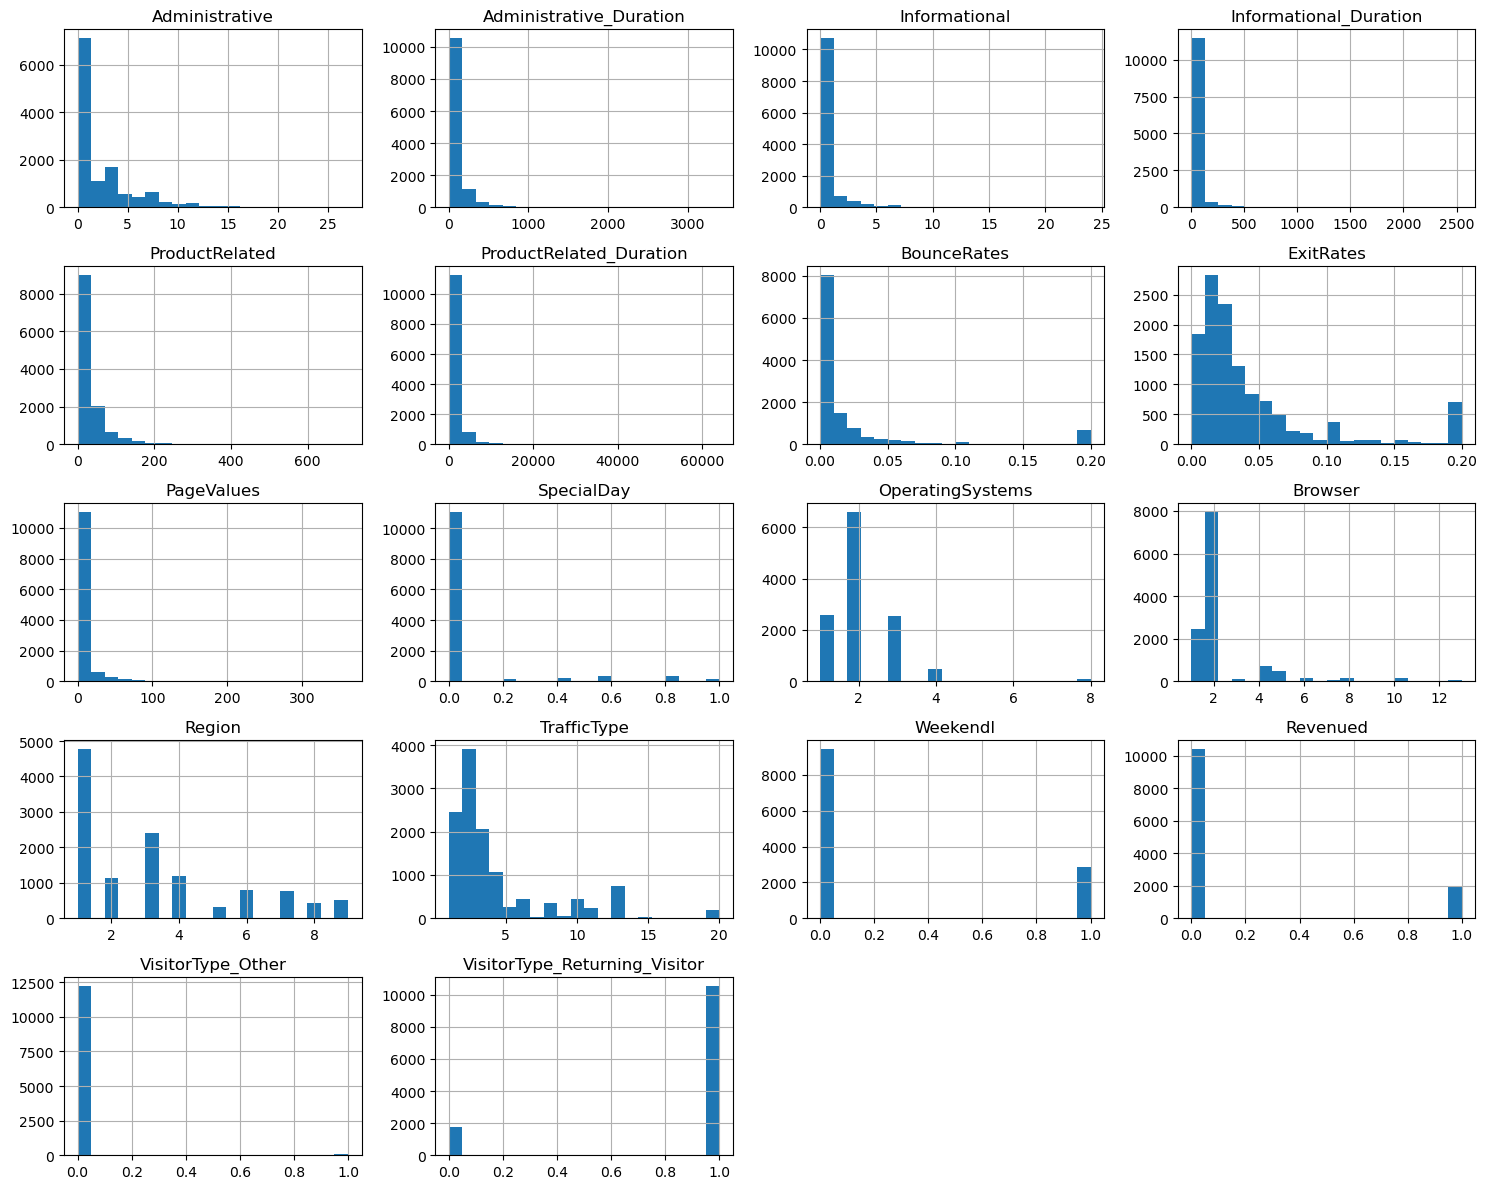

<Figure size 640x480 with 0 Axes>

In [76]:
num_cols = Data.select_dtypes(include=["int64","float64"]).columns

Data[num_cols].hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()
plt.show()
plt.savefig("Numerical Features Distribution.png")

In [77]:
# Most related features to purchase 
corr = Data.corr(numeric_only=True)

print(
    corr["Revenued"]
    .sort_values(ascending=False)
)

Revenued                         1.000000
PageValues                       0.492569
ProductRelated                   0.158538
ProductRelated_Duration          0.152373
Administrative                   0.138917
Informational                    0.095200
Administrative_Duration          0.093587
Informational_Duration           0.070345
Weekendl                         0.029295
Browser                          0.023984
VisitorType_Other                0.007715
TrafficType                     -0.005113
Region                          -0.011595
OperatingSystems                -0.014668
SpecialDay                      -0.082305
VisitorType_Returning_Visitor   -0.103843
BounceRates                     -0.150673
ExitRates                       -0.207071
Name: Revenued, dtype: float64


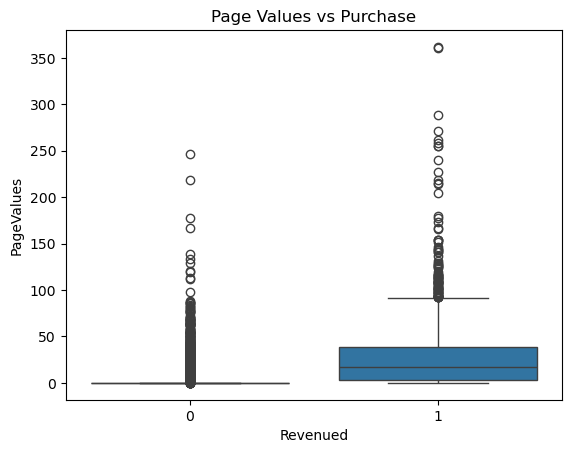

<Figure size 640x480 with 0 Axes>

In [78]:
sns.boxplot(
    x="Revenued",
    y="PageValues",
    data=Data
)

plt.title("Page Values vs Purchase")
plt.show()
plt.savefig("Page Values vs Purchase.png")

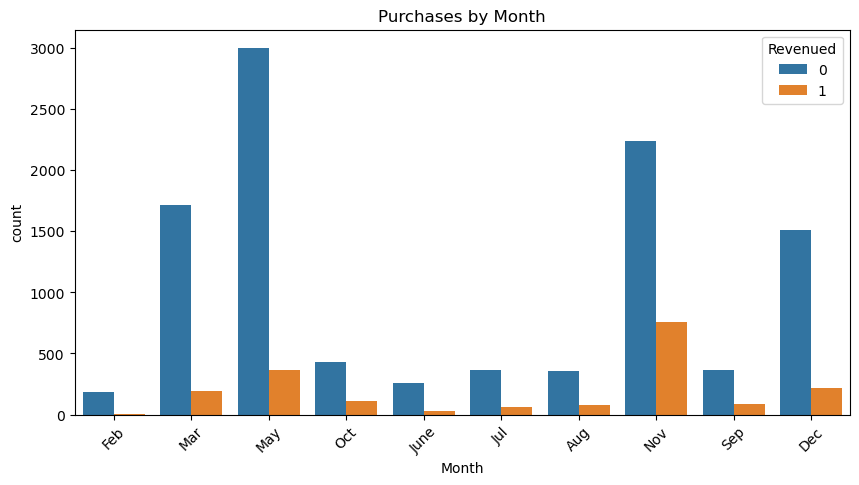

<Figure size 640x480 with 0 Axes>

In [79]:
# Monthly trend
plt.figure(figsize=(10,5))

sns.countplot(
    x="Month",
    hue="Revenued",
    data=Data
)

plt.xticks(rotation=45)
plt.title("Purchases by Month")
plt.show()
plt.savefig("Purchases by Month.png")

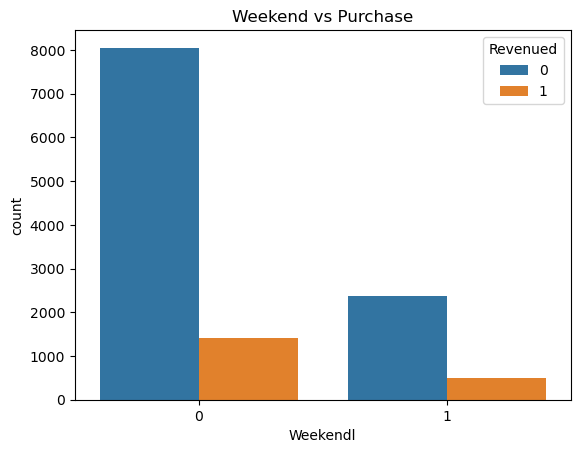

<Figure size 640x480 with 0 Axes>

In [80]:
# Weekend Impact
sns.countplot(
    x="Weekendl",
    hue="Revenued",
    data=Data
)

plt.title("Weekend vs Purchase")
plt.show()
plt.savefig("Weekend vs Purchase.png")

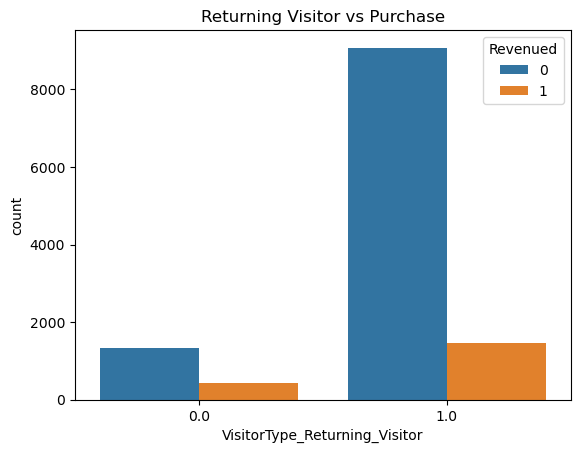

<Figure size 640x480 with 0 Axes>

In [81]:
#Visitor type impact
sns.countplot(
    x="VisitorType_Returning_Visitor",
    hue="Revenued",
    data=Data
)

plt.title("Returning Visitor vs Purchase")
plt.show()
plt.savefig("Returning Visitor vs Purchase.png")

# Using Decision Tree Classifier

In [82]:
# Encoding months
Data = pd.get_dummies(
    Data,
    columns=["Month"],
    drop_first=True
   
)

In [83]:
bool_cols = Data.select_dtypes(include="bool").columns

Data[bool_cols] = Data[bool_cols].astype(int)
Data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,VisitorType_Returning_Visitor,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1.0,0,1,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1.0,0,1,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1.0,0,1,0,0,0,0,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,1.0,0,1,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1.0,0,1,0,0,0,0,0,0,0


In [84]:
x=Data.drop(columns=["Revenued"],axis=1)
y=Data["Revenued"]

In [85]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Revenued, dtype: int64

In [86]:
# Train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
# stratify for balancing data in both test and train


In [87]:
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

Revenued
0    84.529603
1    15.470397
Name: proportion, dtype: float64
Revenued
0    84.509327
1    15.490673
Name: proportion, dtype: float64


In [88]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [92]:
from sklearn.tree import DecisionTreeClassifier
## pruning by maximum depth 
max_depth=[2,3,4,5,6,7,8,9,10]
for depth in max_depth:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train,y_train)
    accuracy=  model.score(x_test,y_test)
    print(f"Depth={depth} and Accuracy={accuracy}")
    

Depth=2 and Accuracy=0.8860502838605029
Depth=3 and Accuracy=0.8969991889699919
Depth=4 and Accuracy=0.8961881589618816
Depth=5 and Accuracy=0.8994322789943228
Depth=6 and Accuracy=0.8957826439578265
Depth=7 and Accuracy=0.8941605839416058
Depth=8 and Accuracy=0.8905109489051095
Depth=9 and Accuracy=0.8888888888888888
Depth=10 and Accuracy=0.8844282238442822


In [94]:
min_samples_split=[10,15,20,25,30,35,40]
for samples in min_samples_split:
     model=DecisionTreeClassifier(min_samples_split=samples)
     model.fit(x_train,y_train)
     accuracy=  model.score(x_test,y_test)
     print(f"Samples={samples} and Accuracy={accuracy}")
   

Samples=10 and Accuracy=0.8686131386861314
Samples=15 and Accuracy=0.8698296836982968
Samples=20 and Accuracy=0.875506893755069
Samples=25 and Accuracy=0.8815896188158961
Samples=30 and Accuracy=0.8803730738037308
Samples=35 and Accuracy=0.8807785888077859
Samples=40 and Accuracy=0.8815896188158961


In [ ]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train,y_train)

path=full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

In [102]:
tree=[]
for alphas in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alphas)
    model.fit(x_train,y_train)

    tree.append((model,alphas))

In [106]:
best_alpha=0
best_accuracy=0
for model,alphas in tree:
    curr_acc=model.score(x_test,y_test)
    if curr_acc>best_accuracy:
        best_accuracy=curr_acc
        best_alpha=alphas
print(best_accuracy)
print(best_alpha)

0.9010543390105434
0.0003942506983869514


In [ ]:
# Best depth=5
# Best min_sample_split=25
# best ccp_alpha=0.0003942506983869514 (post_pruning)

In [107]:
# training model with pruning
best_model=DecisionTreeClassifier(max_depth=5, min_samples_split=25,ccp_alpha=best_alpha)

In [108]:
# fitting model
best_model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,25
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [110]:
y_pred=best_model.predict(x_test)

In [112]:
# Evaluating Model
from sklearn.metrics import f1_score
print("f1 Score:",f1_score(y_test,y_pred))

f1 Score: 0.6457142857142857


In [114]:
# Complete Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy : 0.8994322789943228
Precision: 0.710691823899371
Recall   : 0.5916230366492147
F1 Score : 0.6457142857142857
[[1992   92]
 [ 156  226]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2084
           1       0.71      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.90      2466

